In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [5]:
from google.colab import drive

drive.mount('/content/drive')

train_dir = '/content/drive/MyDrive/problemds/train'
val_dir   = '/content/drive/MyDrive/problemds/val'
test_dir  = '/content/drive/MyDrive/problemds/test'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

print("Classes:", train_ds.class_names)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation")

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


In [7]:
model = Sequential([

    # Input
    layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    data_augmentation,

    # Normalize pixels from [0,255] to [0,1]
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Feature vector
    layers.GlobalAveragePooling2D(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # Binary output
    layers.Dense(1, activation="sigmoid")
])

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 615,201 (2.35 MB)

 Trainable params: 615,201 (2.35 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

In [10]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_cnn_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [11]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        checkpoint
    ]
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.7273 - loss: 0.6103 - precision: 0.7325 - recall: 0.9881
Epoch 1: val_loss improved from None to 0.81872, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 62s 302ms/step - accuracy: 0.7419 - loss: 0.5868 - precision: 0.7429 - recall: 0.9979 - val_accuracy: 0.5000 - val_loss: 0.8187 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.7350 - loss: 0.5783 - precision: 0.7359 - recall: 0.9970
Epoch 2: val_loss improved from 0.81872 to 0.56927, saving model to best_cnn_model.keras

Epoch 2: finished saving model to best_cnn_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 296ms/step - accuracy: 0.7483 - loss: 0.5495 - precision: 0.7515 - recall: 0.9879 - val_accuracy: 0.6250 - val_loss: 0.5693 - val_precision: 0.5833 - val_recall: 0.8750
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - acc

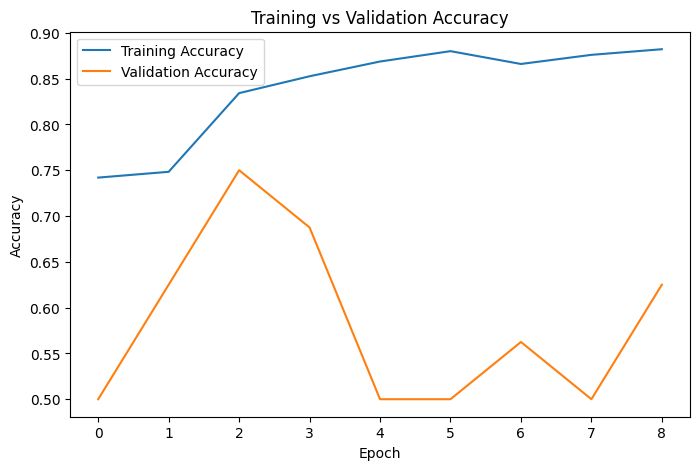

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

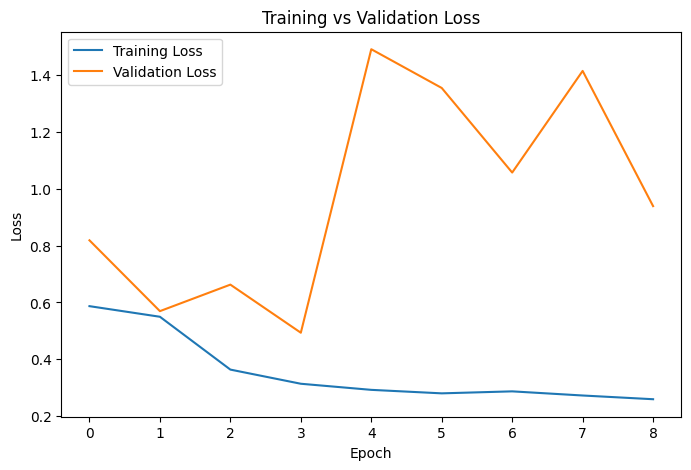

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [14]:
best_model = keras.models.load_model("best_cnn_model.keras")

In [15]:
test_results = best_model.evaluate(test_ds, verbose=1)

print("\nTest Results:")

for name, value in zip(best_model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 197ms/step - accuracy: 0.7965 - loss: 0.4167 - precision: 0.9071 - recall: 0.7513

Test Results:
loss: 0.4167
compile_metrics: 0.7965


In [16]:
y_true = []
y_pred_prob = []

for images, labels in test_ds:

    predictions = best_model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_pred_prob.extend(predictions.flatten())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

# Convert probability to class
y_pred = (y_pred_prob >= 0.5).astype(int)

In [17]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.7964743589743589
Precision: 0.9071207430340558
Recall   : 0.7512820512820513
F1 Score : 0.8218793828892006


In [18]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["NORMAL", "PNEUMONIA"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      NORMAL       0.68      0.87      0.76       234
   PNEUMONIA       0.91      0.75      0.82       390

    accuracy                           0.80       624
   macro avg       0.79      0.81      0.79       624
weighted avg       0.82      0.80      0.80       624

